In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
from scipy import optimize as op
import matplotlib.pyplot as plt

In [2]:
import psutil, os
p = psutil.Process(os.getpid())
print("cpu%:", p.cpu_percent(interval=1.0))
print("affinity:", p.cpu_affinity())
print("nice:", p.nice())


cpu%: 0.0
affinity: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
nice: Priority.NORMAL_PRIORITY_CLASS


In [2]:
N=7               #链长
j=1            #自旋大小
d=int(2*j+1)      #自旋矩阵维度

In [3]:
idd=qeye(d)         #单自旋单位算符

ids=idd             #集体自旋单位算符
for i in range(N-1):
    ids=tensor(ids,idd)

Em=np.zeros((d,d))

em=Qobj(Em)         #单格点空算符

ec=em               #整链空算符
for i in range(N-1):
    ec=tensor(ec,em)

Sx=np.zeros((d,d))
for i in range(d-1):
    m=j-i
    Sx[i,i+1]=((j+m)*(j-m+1))**(1/2)/2
    Sx[i+1,i]=((j+m)*(j-m+1))**(1/2)/2
sx=Qobj(Sx)         #单自旋

Su=np.zeros((d,d))  #最高自旋跃迁算符
Su[1,0]=(j/2)**(1/2)
Su[0,1]=(j/2)**(1/2)
su=Qobj(Su)

Sd=np.zeros((d,d))  #最低自旋跃迁算符
Sd[d-2,d-1]=(j/2)**(1/2)
Sd[d-1,d-2]=(j/2)**(1/2)
sd=Qobj(Sd)

Lu=np.zeros((d,d))  #最高耗散跃迁算符
Lu[0,1]=1
lu=Qobj(Lu)

Ld=np.zeros((d,d))  #最低耗散跃迁算符
Ld[d-1,d-2]=1
ld=Qobj(Ld)

Pu=np.zeros((d,d))  #最高自旋投影
Pu[0,0]=1
pu=Qobj(Pu)

Pd=np.zeros((d,d))  #最低自旋投影
Pd[d-1,d-1]=1
pd=Qobj(Pd)

In [4]:
H0=ec               #哈密顿量
for i in range(N):
    if i==0:
        h0=sx
    else:
        h0=idd
    for k in range(N-1):
        if k+1==i:
            h0=tensor(h0,sx)
        else:
            h0=tensor(h0,idd)
    H0=H0+h0

H=H0               #疤痕哈密顿量
for i in range(N):
    if i==0:
        h1=pu
        h2=su
    elif i==N-1:
        h1=sd
        h2=pd
    else:
        h1=idd
        h2=idd
    for k in range(N-1):
        if k+1==i:
            h1=tensor(h1,pu)
            h2=tensor(h2,su)
        elif k==i:
            h1=tensor(h1,sd)
            h2=tensor(h2,pd)
        else:
            h1=tensor(h1,idd)
            h2=tensor(h2,idd)
    H=H-h1-h2

In [5]:
def Lind(c,b):
    gamma=((2*j)**(1/2))*c
    L=[]                #lindblad算符
    for i in range(N):
        if i==0:
            sigma1=pu
            sigma2=lu
            sigma3=pu
        elif i==N-1:
            sigma1=pd
            sigma2=pd
            sigma3=ld
        else:
            sigma1=idd
            sigma2=idd
            sigma3=idd
        for k in range(N-1):
            if k+1==i:
                sigma1=tensor(sigma1,pu)
                sigma2=tensor(sigma2,lu)
                sigma3=tensor(sigma3,pu)
            elif k==i:
                sigma1=tensor(sigma1,pd)
                sigma2=tensor(sigma2,pd)
                sigma3=tensor(sigma3,ld)
            else:
                sigma1=tensor(sigma1,idd)
                sigma2=tensor(sigma2,idd)
                sigma3=tensor(sigma3,idd)
        ldb=(gamma**(1/2))*(sigma1-(1j/b)*sigma2-(1j/b)*sigma3)
        L.append(ldb)
    return(L)

In [6]:
def st(i):
    state=basis(d,i)
    return(state)

In [7]:
Pb=ids
for i in range(N):
    if i==0:
        pp=pu
    elif i==N-1:
        pp=pd
    else:
        pp=idd
    for k in range(N-1):
        if k+1==i:
            pp=tensor(pp,pu)
        elif k==i:
            pp=tensor(pp,pd)
        else:
            pp=tensor(pp,idd)
    Pb=Pb*(ids-pp)
Ut=ec
for i1 in range(d):
    for i2 in range(d):
        for i3 in range(d):
            for i4 in range(d):
                for i5 in range(d):
                    for i6 in range(d):
                        for i7 in range(d):
                            Ut=Ut+tensor(st(i2),st(i3),st(i4),st(i5),st(i6),st(i7),st(i1))*tensor(st(i1).dag(),st(i2).dag(),st(i3).dag(),st(i4).dag(),st(i5).dag(),st(i6).dag(),st(i7).dag())

Pt=(ids+Ut+(Ut**2)+(Ut**3)+(Ut**4)+(Ut**5)+(Ut**6))/N

In [8]:
Hp=Pb*Pt*H*Pt*Pb
Ei=Hp.eigenstates()[0]
Vi=Hp.eigenstates()[1]

In [9]:
En=[]
Vn=[]
for i in range(d**N):
    if abs(Ei[i])>10**(-12):
        En.append(Ei[i])
        Vn.append(Vi[i])

In [10]:
psi0=tensor(st(0),st(0),st(0),st(0),st(0),st(0),st(0))
ovl=np.zeros(len(En))
for i in range(len(En)):
    if abs((psi0.dag()*Vn[i]).full()[0,0])!=0:
        ovl[i]=np.log(abs((psi0.dag()*Vn[i]).full()[0,0]))
    else:
        ovl[i]=-10

<function matplotlib.pyplot.show(*args, **kw)>

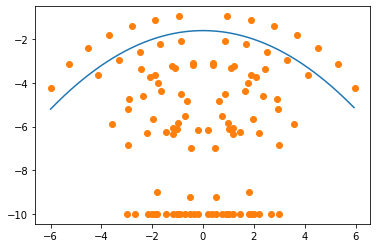

In [11]:
#区分和提取疤痕态
x=np.zeros(200)
y=np.zeros(200)
for i in range(200):
    x[i]=-6+0.06*i
    y[i]=-0.1*x[i]**2-1.6

plt.plot(x,y)
plt.plot(En,ovl,'o')
plt.show

In [12]:
#找到了疤痕态，将非疤痕态另外储存
Es=[]
Vs=[]
Ens=[]
Vns=[]
ovls=[]
ovlns=[]
for i in range(len(En)):
    e=En[i]
    ov=-0.1*e**2-1.6
    if ovl[i]>ov:
        Es.append(En[i])
        Vs.append(Vn[i])
        ovls.append(ovl[i])
    else:
        Ens.append(En[i])
        Vns.append(Vn[i])
        ovlns.append(ovl[i])

([], <a list of 0 Text major ticklabel objects>)

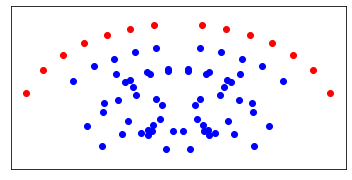

In [13]:
plt.figure(figsize=(6,3))
plt.plot(Es,ovls,'o',color='r')
plt.plot(Ens,ovlns,'o',color='b')
plt.ylim([-8,0])
#plt.xlabel('E')
#plt.ylabel('overlap')
plt.xticks([])
plt.yticks([])
#plt.savefig('ovlp')

In [14]:
tlist=np.linspace(0,40,200)
cn=400
trajn=500

In [15]:
np.show_config()

blas_mkl_info:
    libraries = ['mkl_rt']
    library_dirs = ['C:/Users/20897/anaconda3\\Library\\lib']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['C:\\Program Files (x86)\\IntelSWTools\\compilers_and_libraries_2019.0.117\\windows\\mkl', 'C:\\Program Files (x86)\\IntelSWTools\\compilers_and_libraries_2019.0.117\\windows\\mkl\\include', 'C:\\Program Files (x86)\\IntelSWTools\\compilers_and_libraries_2019.0.117\\windows\\mkl\\lib', 'C:/Users/20897/anaconda3\\Library\\include']
blas_opt_info:
    libraries = ['mkl_rt']
    library_dirs = ['C:/Users/20897/anaconda3\\Library\\lib']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['C:\\Program Files (x86)\\IntelSWTools\\compilers_and_libraries_2019.0.117\\windows\\mkl', 'C:\\Program Files (x86)\\IntelSWTools\\compilers_and_libraries_2019.0.117\\windows\\mkl\\include', 'C:\\Program Files (x86)\\IntelSWTools\\compilers_and_libraries_2019.0.117\\windows\\mkl\\lib', 

In [ ]:
emc1=mcsolve(H0, Vs[0], tlist,Lind(cn,cn), [Vs[0]*Vs[0].dag()], ntraj=trajn)
opts = Options(rhs_reuse=True)
emc2=mcsolve(H0, Vs[1], tlist,Lind(cn,cn), [Vs[1]*Vs[1].dag()], ntraj=trajn, options=opts)
emc3=mcsolve(H0, Vs[2], tlist,Lind(cn,cn), [Vs[2]*Vs[2].dag()], ntraj=trajn, options=opts)
emc4=mcsolve(H0, Vs[3], tlist,Lind(cn,cn), [Vs[3]*Vs[3].dag()], ntraj=trajn, options=opts)

In [18]:
import psutil, time
print(psutil.cpu_freq())

In [19]:
import psutil
print(psutil.cpu_freq(percpu=True)[:8])
print("logical:", psutil.cpu_count(logical=True), "physical:", psutil.cpu_count(logical=False))

[scpufreq(current=2500.0, min=0.0, max=2500.0)]
logical: 16 physical: 10


In [59]:
emcN1=mcsolve(H0, Vns[0], tlist,Lind(cn,cn), [Vns[0]*Vns[0].dag()], ntraj=trajn, options=opts)
emcN2=mcsolve(H0, Vns[1], tlist,Lind(cn,cn), [Vns[1]*Vns[1].dag()], ntraj=trajn, options=opts)
emcN3=mcsolve(H0, Vns[2], tlist,Lind(cn,cn), [Vns[2]*Vns[2].dag()], ntraj=trajn, options=opts)
emcN4=mcsolve(H0, Vns[3], tlist,Lind(cn,cn), [Vns[3]*Vns[3].dag()], ntraj=trajn, options=opts)

10.0%. Run time:  47.16s. Est. time left: 00:00:07:04
20.0%. Run time:  86.57s. Est. time left: 00:00:05:46
30.0%. Run time: 120.17s. Est. time left: 00:00:04:40
40.0%. Run time: 176.19s. Est. time left: 00:00:04:24
50.0%. Run time: 212.66s. Est. time left: 00:00:03:32
60.0%. Run time: 247.43s. Est. time left: 00:00:02:44
70.0%. Run time: 313.46s. Est. time left: 00:00:02:14
80.0%. Run time: 354.86s. Est. time left: 00:00:01:28
90.0%. Run time: 401.68s. Est. time left: 00:00:00:44
100.0%. Run time: 436.12s. Est. time left: 00:00:00:00
Total run time: 436.19s
10.0%. Run time:  58.87s. Est. time left: 00:00:08:49
20.0%. Run time:  92.46s. Est. time left: 00:00:06:09
30.0%. Run time: 141.02s. Est. time left: 00:00:05:29
40.0%. Run time: 191.77s. Est. time left: 00:00:04:47
50.0%. Run time: 231.02s. Est. time left: 00:00:03:51
60.0%. Run time: 283.93s. Est. time left: 00:00:03:09
70.0%. Run time: 322.78s. Est. time left: 00:00:02:18
80.0%. Run time: 369.65s. Est. time left: 00:00:01:32
90.

In [102]:
qsave(emc1, 'evolveMC_Scar1')
qsave(emc2, 'evolveMC_Scar2')
qsave(emc3, 'evolveMC_Scar3')
qsave(emc4, 'evolveMC_Scar4')
qsave(emcN1, 'evolveMC_NScar1')
qsave(emcN2, 'evolveMC_NScar2')
qsave(emcN3, 'evolveMC_NScar3')
qsave(emcN4, 'evolveMC_NScar4')

In [23]:
emc1=qload('evolveMC_Scar1')
emc2=qload('evolveMC_Scar2')
emc3=qload('evolveMC_Scar3')
emc4=qload('evolveMC_Scar4')
emcN1=qload('evolveMC_NScar1')
emcN2=qload('evolveMC_NScar2')
emcN3=qload('evolveMC_NScar3')
emcN4=qload('evolveMC_NScar4')

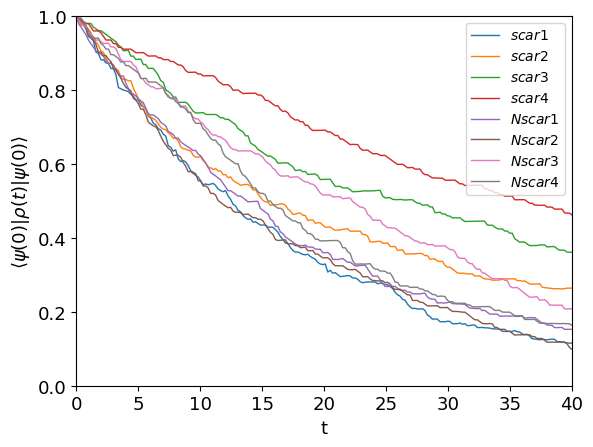

In [33]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, emc1.expect[0],linewidth=1.0, label=r'$scar1$')
axes.plot(tlist, emc2.expect[0],linewidth=1.0, label=r'$scar2$')
axes.plot(tlist, emc3.expect[0],linewidth=1.0, label=r'$scar3$')
axes.plot(tlist, emc4.expect[0],linewidth=1.0, label=r'$scar4$')
axes.plot(tlist, emcN1.expect[0],linewidth=1.0, label=r'$Nscar1$')
axes.plot(tlist, emcN2.expect[0],linewidth=1.0, label=r'$Nscar2$')
axes.plot(tlist, emcN3.expect[0],linewidth=1.0, label=r'$Nscar3$')
axes.plot(tlist, emcN4.expect[0],linewidth=1.0, label=r'$Nscar4$')
plt.xlabel('t',fontsize=13)
plt.ylabel(r'$\langle \psi(0) | \rho(t) |\psi(0) \rangle$',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim([0,40])
plt.ylim([0,1])
axes.legend(loc=1);

In [17]:
Jt1=[]
Jt2=[]
Jt3=[]
Jt4=[]
JtN1=[]
JtN2=[]
JtN3=[]
JtN4=[]
for i in range(trajn):
    emt=emc1.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt1.append(emt[i][k])
    emt=emc2.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt2.append(emt[i][k])
    emt=emc3.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt3.append(emt[i][k])
    emt=emc4.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt4.append(emt[i][k])
    emt=emcN1.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            JtN1.append(emt[i][k])
    emt=emcN2.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            JtN2.append(emt[i][k])
    emt=emcN3.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            JtN3.append(emt[i][k])
    emt=emcN4.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            JtN4.append(emt[i][k])

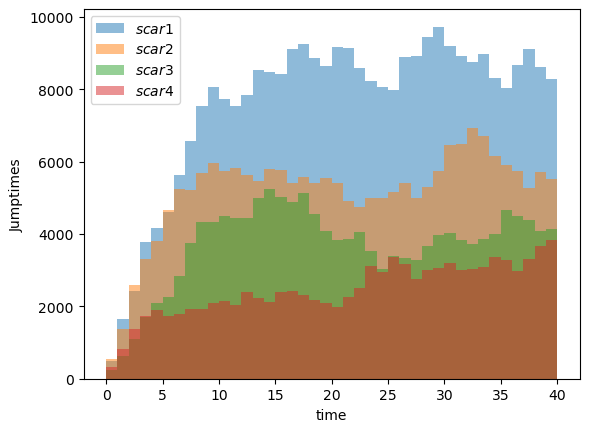

In [18]:
#Jump的出现随时间的分布图
plt.hist(Jt1,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar1$')
plt.hist(Jt2,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar2$')
plt.hist(Jt3,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar3$')
plt.hist(Jt4,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar4$')
plt.legend()
plt.xlabel('time')
plt.ylabel('Jumptimes')
plt.show()

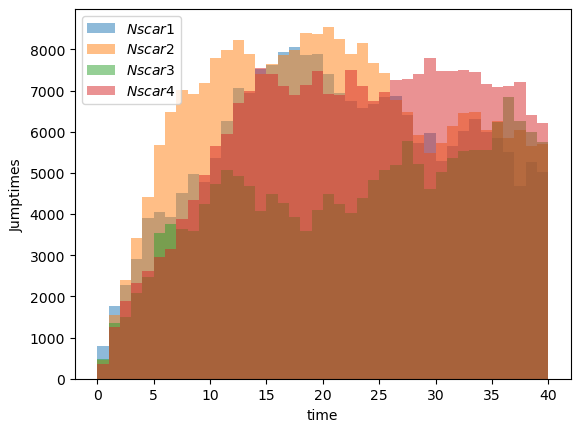

In [19]:
#Jump的出现随时间的分布图
plt.hist(JtN1,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$Nscar1$')
plt.hist(JtN2,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$Nscar2$')
plt.hist(JtN3,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$Nscar3$')
plt.hist(JtN4,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$Nscar4$')
plt.legend()
plt.xlabel('time')
plt.ylabel('Jumptimes')
plt.show()

In [17]:
emc5=mcsolve(H0, Vs[4], tlist,Lind(cn,cn), [Vs[4]*Vs[4].dag()], ntraj=trajn)
opts = Options(rhs_reuse=True)
emc6=mcsolve(H0, Vs[5], tlist,Lind(cn,cn), [Vs[5]*Vs[5].dag()], ntraj=trajn, options=opts)
emc7=mcsolve(H0, Vs[6], tlist,Lind(cn,cn), [Vs[6]*Vs[6].dag()], ntraj=trajn, options=opts)

10.0%. Run time:  19.16s. Est. time left: 00:00:02:52
20.0%. Run time:  43.50s. Est. time left: 00:00:02:53
30.0%. Run time: 143.60s. Est. time left: 00:00:05:35
40.0%. Run time: 231.23s. Est. time left: 00:00:05:46
50.0%. Run time: 381.54s. Est. time left: 00:00:06:21
60.0%. Run time: 609.52s. Est. time left: 00:00:06:46
70.0%. Run time: 726.79s. Est. time left: 00:00:05:11
80.0%. Run time: 761.31s. Est. time left: 00:00:03:10
90.0%. Run time: 834.20s. Est. time left: 00:00:01:32
100.0%. Run time: 961.98s. Est. time left: 00:00:00:00
Total run time: 962.06s
10.0%. Run time:  16.38s. Est. time left: 00:00:02:27
20.0%. Run time:  33.36s. Est. time left: 00:00:02:13
30.0%. Run time:  63.81s. Est. time left: 00:00:02:28
40.0%. Run time: 114.24s. Est. time left: 00:00:02:51
50.0%. Run time: 193.74s. Est. time left: 00:00:03:13
60.0%. Run time: 227.98s. Est. time left: 00:00:02:31
70.0%. Run time: 290.23s. Est. time left: 00:00:02:04
80.0%. Run time: 446.29s. Est. time left: 00:00:01:51
90.

In [42]:
qsave(emc5, 'evolveMC_Scar5')
qsave(emc6, 'evolveMC_Scar6')
qsave(emc7, 'evolveMC_Scar7')

In [25]:
emc5=qload('evolveMC_Scar5')
emc6=qload('evolveMC_Scar6')
emc7=qload('evolveMC_Scar7')

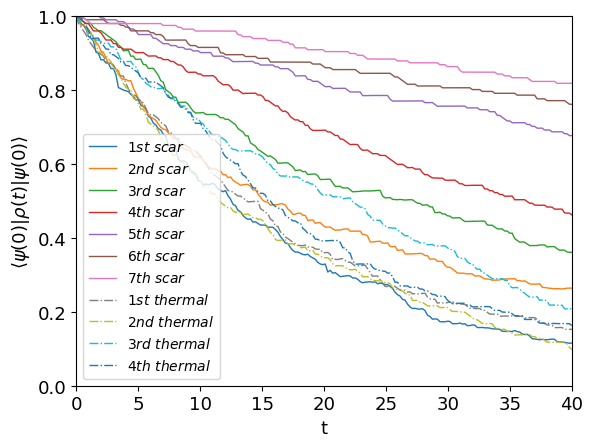

In [40]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, emc1.expect[0],linewidth=1.0,  label=r'$1st\ scar$')
axes.plot(tlist, emc2.expect[0],linewidth=1.0,  label=r'$2nd\ scar$')
axes.plot(tlist, emc3.expect[0],linewidth=1.0,  label=r'$3rd\ scar$')
axes.plot(tlist, emc4.expect[0],linewidth=1.0,  label=r'$4th\ scar$')
axes.plot(tlist, emc5.expect[0],linewidth=1.0,  label=r'$5th\ scar$')
axes.plot(tlist, emc6.expect[0],linewidth=1.0,  label=r'$6th\ scar$')
axes.plot(tlist, emc7.expect[0],linewidth=1.0,  label=r'$7th\ scar$')
axes.plot(tlist, emcN1.expect[0],linewidth=1.0, linestyle='-.', label=r'$1st\ thermal$')
axes.plot(tlist, emcN2.expect[0],linewidth=1.0, linestyle='-.', label=r'$2nd\ thermal$')
axes.plot(tlist, emcN3.expect[0],linewidth=1.0, linestyle='-.', label=r'$3rd\ thermal$')
axes.plot(tlist, emcN4.expect[0],linewidth=1.0, linestyle='-.', label=r'$4th\ thermal$')
plt.xlabel('t',fontsize=13)
plt.ylabel(r'$\langle \psi(0) | \rho(t) |\psi(0) \rangle$',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim([0,40])
plt.ylim([0,1])
plt.legend()
#plt.savefig('decayQTD')

In [23]:
Jt5=[]
Jt6=[]
Jt7=[]
for i in range(trajn):
    emt=emc5.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt5.append(emt[i][k])
    emt=emc6.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt6.append(emt[i][k])
    emt=emc7.col_times
    if len(emt[i])>0:
        jti=len(emt[i])
        for k in range(jti):
            Jt7.append(emt[i][k])

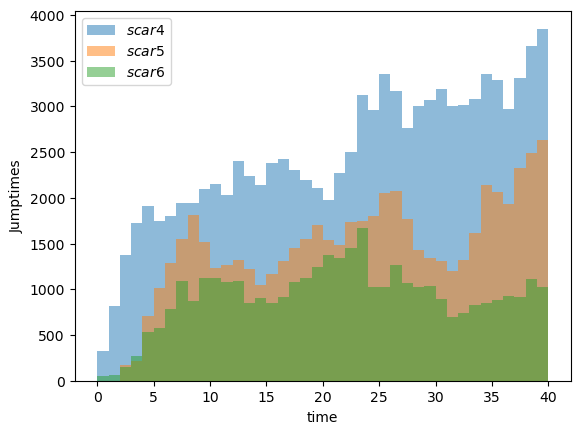

In [24]:
#Jump的出现随时间的分布图
#plt.hist(Jt1,bins=40,range=[0,40],density=False, alpha=1, label=r'$scar1$')
#plt.hist(Jt2,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar2$')
#plt.hist(Jt3,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar3$')
plt.hist(Jt4,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar4$')
plt.hist(Jt5,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar5$')
plt.hist(Jt6,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar6$')
#plt.hist(Jt7,bins=40,range=[0,40],density=False, alpha=0.5, label=r'$scar7$')
plt.legend()
plt.xlabel('time')
plt.ylabel('Jumptimes')
plt.show()

In [19]:
def f(x,A):
    return(np.exp(-A*x))

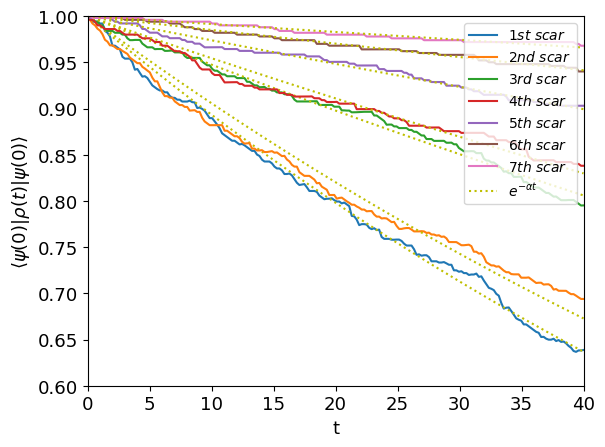

In [21]:
drate=[]
As1 =op.curve_fit(f,tlist,emc1.expect[0])[0]
drate.append(As1[0])
emsf1=f(tlist,As1)
As2 =op.curve_fit(f,tlist,emc2.expect[0])[0]
drate.append(As2[0])
emsf2=f(tlist,As2)
As3 =op.curve_fit(f,tlist,emc3.expect[0])[0]
drate.append(As3[0])
emsf3=f(tlist,As3)
As4 =op.curve_fit(f,tlist,emc4.expect[0])[0]
drate.append(As4[0])
emsf4=f(tlist,As4)
As5 =op.curve_fit(f,tlist,emc5.expect[0])[0]
drate.append(As5[0])
emsf5=f(tlist,As5)
As6 =op.curve_fit(f,tlist,emc6.expect[0])[0]
drate.append(As6[0])
emsf6=f(tlist,As6)
As7 =op.curve_fit(f,tlist,emc7.expect[0])[0]
drate.append(As7[0])
emsf7=f(tlist,As7)
fig, axes = plt.subplots(1,1)
axes.plot(tlist, emc1.expect[0], label=r'$1st\ scar$')
axes.plot(tlist,emsf1,linestyle=':',color='y')
axes.plot(tlist, emc2.expect[0], label=r'$2nd\ scar$')
axes.plot(tlist,emsf2,linestyle=':',color='y')
axes.plot(tlist, emc3.expect[0], label=r'$3rd\ scar$')
axes.plot(tlist,emsf3,linestyle=':',color='y')
axes.plot(tlist, emc4.expect[0], label=r'$4th\ scar$')
axes.plot(tlist,emsf4,linestyle=':',color='y')
axes.plot(tlist, emc5.expect[0], label=r'$5th\ scar$')
axes.plot(tlist,emsf5,linestyle=':',color='y')
axes.plot(tlist, emc6.expect[0], label=r'$6th\ scar$')
axes.plot(tlist,emsf6,linestyle=':',color='y')
axes.plot(tlist, emc7.expect[0], label=r'$7th\ scar$')
axes.plot(tlist,emsf7,linestyle=':',color='y', label=r'$e^{-\alpha t}$')
plt.xlabel('t',fontsize=13)
plt.ylabel(r'$\langle \psi(0) | \rho(t) |\psi(0) \rangle$',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim([0,40])
plt.ylim([0.6,1])
axes.legend(loc=1)
plt.savefig('decayfit')

In [22]:
rdd=idd
for i in range(N-3):
    rdd=tensor(rdd,idd)
py=(tensor(st(0),st(1))+tensor(st(1),st(2)))/(2**(1/2))
Py=tensor(py*py.dag(),rdd)
expy=[]
Esh=[]
for i in range(7):
    expy.append(np.real((Vs[i].dag()*Py*Vs[i]).full()[0,0]))
    Esh.append(Es[i])

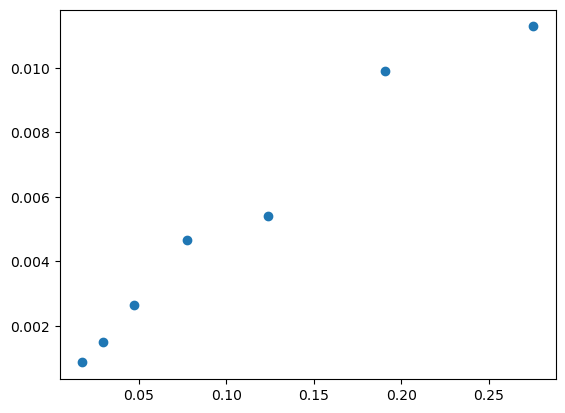

In [23]:
plt.plot(expy,drate,'o')

In [66]:
drate

[0.055797600518394205,
 0.04015325884929159,
 0.02692481975107408,
 0.018929452224172316,
 0.009575037270011098,
 0.00708703675565726,
 0.004905319650330067]

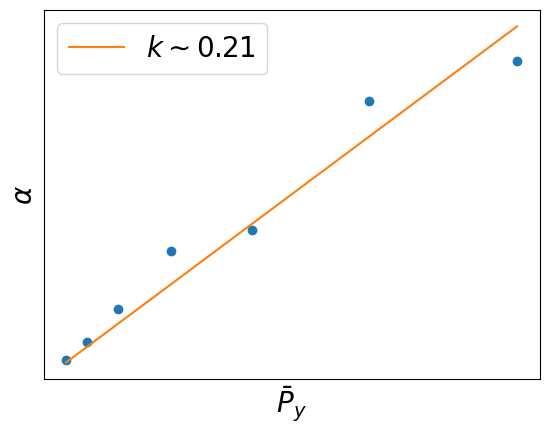

In [24]:
def ff(x,A):
    return(A*x)
Ass=op.curve_fit(ff,expy,drate)[0]
dratefit=ff(expy,Ass)
fig, axes = plt.subplots(1,1)
plt.plot(expy,drate,'o')
plt.plot(expy,dratefit,label=r'$k\sim 0.21$',)
plt.xticks([])
plt.yticks([])
plt.xlabel(r'$\bar{P}_y$',fontsize=20)
plt.ylabel(r'$\alpha$',fontsize=20)
axes.legend(loc=2,fontsize=20)
plt.savefig('pydecay')

In [25]:
Ass

array([0.04534823])

In [29]:
for i in range(4):
    expy.append(np.real((Vns[i].dag()*Py*Vns[i]).full()[0,0]))
    Esh.append(Ens[i])

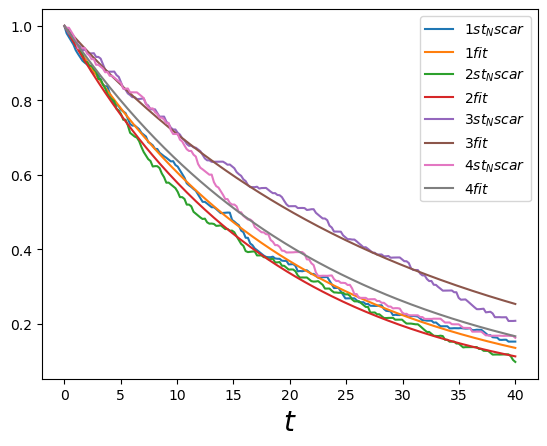

In [30]:
AsN1 =op.curve_fit(f,tlist,emcN1.expect[0])[0]
drate.append(AsN1)
emNsf1=f(tlist,AsN1)
AsN2 =op.curve_fit(f,tlist,emcN2.expect[0])[0]
drate.append(AsN2)
emNsf2=f(tlist,AsN2)
AsN3 =op.curve_fit(f,tlist,emcN3.expect[0])[0]
drate.append(AsN3)
emNsf3=f(tlist,AsN3)
AsN4 =op.curve_fit(f,tlist,emcN4.expect[0])[0]
drate.append(AsN4)
emNsf4=f(tlist,AsN4)
fig, axes = plt.subplots(1,1)
axes.plot(tlist, emcN1.expect[0],label=r'$1st_Nscar$')
axes.plot(tlist,emNsf1,label=r'$1fit$')
axes.plot(tlist, emcN2.expect[0],label=r'$2st_Nscar$')
axes.plot(tlist,emNsf2,label=r'$2fit$')
axes.plot(tlist, emcN3.expect[0],label=r'$3st_Nscar$')
axes.plot(tlist,emNsf3,label=r'$3fit$')
axes.plot(tlist, emcN4.expect[0],label=r'$4st_Nscar$')
axes.plot(tlist,emNsf4,label=r'$4fit$')
axes.set_xlabel(r'$t$', fontsize=20)
axes.legend(loc=1);

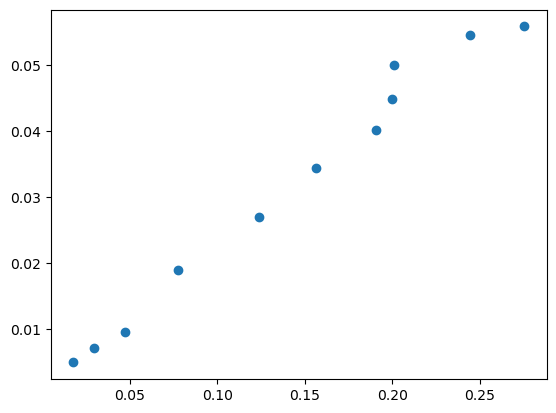

In [31]:
plt.plot(expy,drate,'o')